# Decision Tree Plotting

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

In [30]:
# Load the full dataset
file_name = "Data/NASA_AirQuality_Excel_Analysis.xlsx"
df = pd.read_excel(file_name)

In [31]:
# 1. Prepare the Data
# Ṣelecting key features: Particulate Matter (PM2.5, PM10), AQI, Nitrogen Dioxide (NO2) and Carbon Dioxide (CO)
feature_cols_for_tree = ["PM2.5", "PM10", "AQI", "NO2", "CO"]
target_col = "AQI_Category"

In [32]:
X = df[feature_cols_for_tree]
y = df[target_col]

In [33]:
# Encode the target variable (AQI_Category) since Decision Tree work with numerical labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_name = le.classes_

In [34]:
# 2. Train Decision Tree
# Limiting max_depth to 3 for a readable plot
dt = DecisionTreeClassifier(max_depth = 3, random_state = 42)
dt.fit(X, y_encoded)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
# 3. Plot the Tree
plt.figure(figsize = (30, 18))
plot_tree(
    dt,
    filled = True,
    feature_names = feature_cols_for_tree,
    class_names = class_name,
    rounded = True,
    fontsize = 12,
    proportion = False
)
plt.title("Decision Tree Classifier (Max Depth 3) for AQI Category", fontsize = 24)
plt.savefig("decision_tree_aqi_category_v2.png")
plt.close()
print("Decision tree plot successfully regenerated and saved as decision_tree_aqi_category_v2.png")

Decision tree plot successfully regenerated and saved as decision_tree_aqi_category_v2.png


# KNN

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [37]:
# 1. Load Data
file_name = "Data/NASA_AirQuality_Excel_Analysis.xlsx"
df = pd.read_excel(file_name)

# Handle potenstial whitespace in column names
df.columns = df.columns.str.strip()

# 2. Prepare Data
feature_cols = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3", "Temperature", "Humidity", "WindSpeed", "Rainfall", "Pressure", "Visibility", "UVIndex", "AQI"]
target_col = "AQI_Category"

X = df[feature_cols]
y = df[target_col]

# 3. Encode Target Variable (y)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# 4. Split Data (70% train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size = 0.3, random_state = 42, stratify = y_encoded)

# 5. Scale Features (Crucial for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train KNN Classifier (K=5)
k = 5
knn = KNeighborsClassifier(n_neighbors = k)
knn.fit(X_train_scaled, y_train)

# 7. Make Predictions and Evaluate
y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names = class_names, zero_division = 0)

print("\n--- Corrected KNN Model Performance (k=5) ---")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)

# Print the first few predictions vs actual for a quick check
y_test_decoded = le.inverse_transform(y_test)
y_pred_decoded = le.inverse_transform(y_pred)

results_df = pd.DataFrame({
    "Actual_Category": y_test_decoded,
    "Predicted_Category": y_pred_decoded
})
print("\nFirst 5 Predictions vs Actual:")
print(results_df.head())


--- Corrected KNN Model Performance (k=5) ---
Accuracy: 0.8990

Classification Report:
                 precision    recall  f1-score   support

          Good       0.00      0.00      0.00        39
      Moderate       0.86      0.83      0.84       751
     Unhealthy       0.91      0.97      0.94      2394
Very Unhealthy       0.60      0.14      0.23       104

      accuracy                           0.90      3288
     macro avg       0.59      0.49      0.50      3288
  weighted avg       0.88      0.90      0.88      3288


First 5 Predictions vs Actual:
  Actual_Category Predicted_Category
0       Unhealthy          Unhealthy
1       Unhealthy          Unhealthy
2       Unhealthy          Unhealthy
3       Unhealthy          Unhealthy
4       Unhealthy          Unhealthy


In [38]:
# Determine Optimal K (Err Rate vs K)
error_rate = []
max_k = 30

In [39]:
# Calculate error rate for K values from 1 to max_k 
for i in range(1, max_k + 1):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    error_rate.append(1 - accuracy_score(y_test, y_pred))
    

In [40]:
# Find K value with the minimum error rate
min_error = min(error_rate)
optimal_k = np.argmin(error_rate) + 1

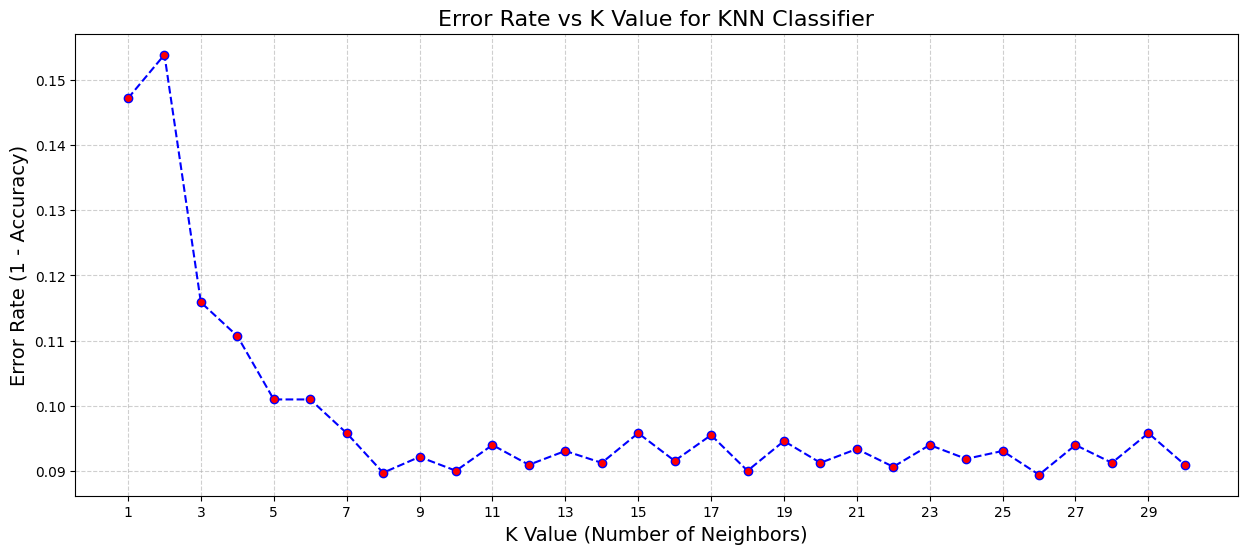

In [41]:
# Plot the results
plt.figure(figsize=(15, 6))
plt.plot(range(1, max_k + 1), error_rate, color = "blue", linestyle = "dashed", marker = "o", markerfacecolor = "red", markersize = 6)
plt.title("Error Rate vs K Value for KNN Classifier", fontsize = 16)
plt.xlabel("K Value (Number of Neighbors)", fontsize = 14)
plt.ylabel("Error Rate (1 - Accuracy)", fontsize = 14)
plt.xticks(range(1, max_k + 1, 2))
plt.grid(True, linestyle = "--", alpha = 0.6)


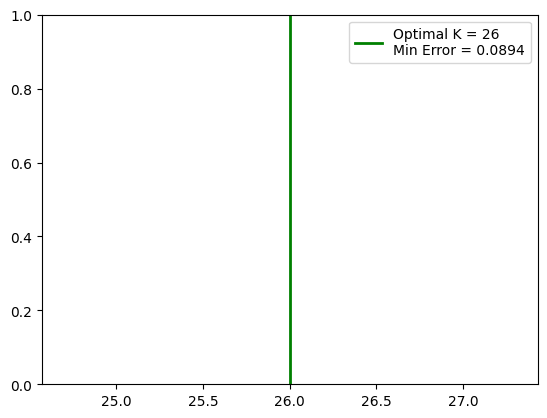

In [42]:
# Add a marker for the optimal K value
plt.axvline(x = optimal_k, color = "green", linestyle = "-", linewidth = 2, label = f"Optimal K = {optimal_k}\nMin Error = {min_error:.4f}")
plt.legend()
plt.savefig("knn_error_rate_vs_k.png")

# Metrics Plot

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [44]:
# Evaluate Decision Tree (DT)
dt = DecisionTreeClassifier(random_state = 42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

In [45]:
# Evaluate K-Nearest Neighbors (KNN) at Optimal K=26
k_optimal = 26
knn = KNeighborsClassifier(n_neighbors = k_optimal)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

In [46]:
# Create Comparison DataFrame
model_names = ["Decision Tree", f"KNN (K={k_optimal})"]
accuracies = [accuracy_dt, accuracy_knn]

metrics_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

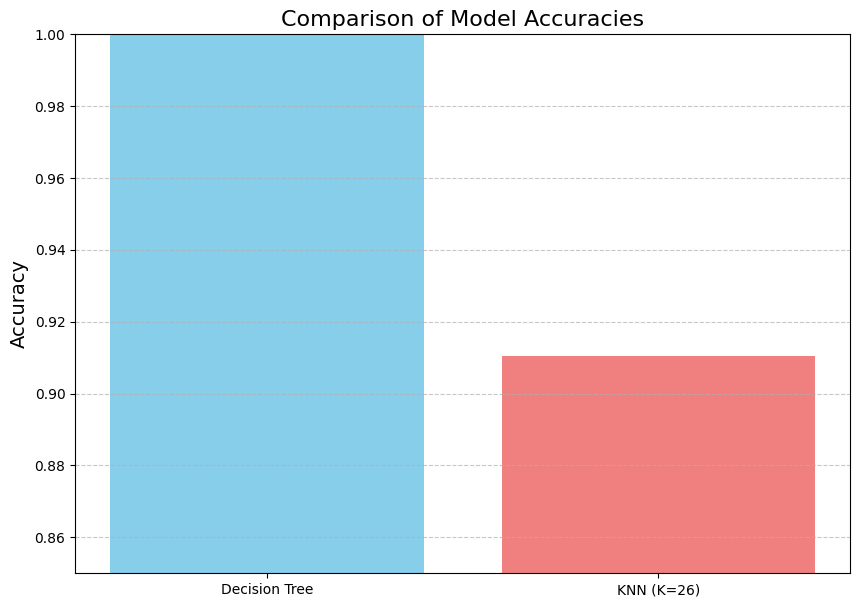

In [47]:
# Plot Matrics
plt.figure(figsize = (10, 7))
bars = plt.bar(metrics_df["Model"], metrics_df["Accuracy"], color = ["skyblue", "lightcoral"])
plt.title("Comparison of Model Accuracies", fontsize = 16)
plt.ylabel("Accuracy", fontsize = 14)
plt.ylim(0.85, 1.0)
plt.grid(axis = "y", linestyle = "--", alpha = 0.7)

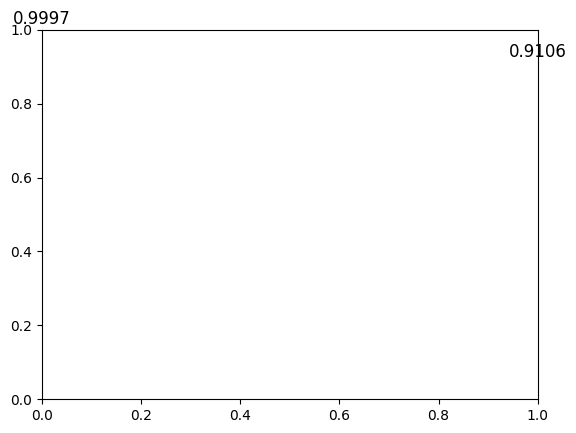

In [48]:
# Add Accuracy values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f}", ha = "center", va = "bottom", fontsize = 12)
plt.savefig("model_accuracy_comparision.png")

# SVM Model with Hyperparameter Tuning Code

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [57]:
# 1. Load and Prepare Data
file_name = "Data/NASA_AirQuality_Excel_Analysis.xlsx"
df = pd.read_excel(file_name)
df.columns = df.columns.str.strip()

# Define features and target
feature_cols = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3", "Temperature", "Humidity", "WindSpeed", "Rainfall", "Pressure", "Visibility", "UVIndex", "AQI"]
target_col = "AQI_Category"

X = df[feature_cols]
y = df[target_col]
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Split Data (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size = 0.3, random_state = 42, stratify = y_encoded)

# Scale Features (Essential for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Define Parameter Grid for Grid Search
param_grid = {
    "C": [1, 10],       # Regularization parameter
    "kernel": ["rbf"],   # Kernel function
    "gamma": ["scale"]  # Kernel coefficient
}
# 3. Perform Grid Search (Hyperparameter Tuning)
grid_search = GridSearchCV(SVC(random_state = 42), param_grid, cv = 3, scoring = "accuracy", n_jobs = -1, verbose = 1)
grid_search.fit(X_train_scaled, y_train)

# 4. Train Final Model (Best Estimator) and Evaluate
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names = class_names, zero_division = 0)

print("\n--- SVM Hyperparameter Tuning Results ---")
# Prints the optimal combination of parameters found by Grid Search
print(f"Best Parameters found: {grid_search.best_params_}")
# Prints the cross-validation score achieved by the best parameters
print(f"Best Cross-Validation Score (Accuracy): {grid_search.best_score_:.4f}")
print("\n--- SVM Model Performance (Best Estimator) ---")
# Prints the accuracy on the held-out test set
print(f"Test Set Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
# Prints the detailed classification metrics (precision, recall, f1-score)
print(classification_report(y_test, y_pred, target_names = class_names, zero_division =0))
print("\nBest parameters saved to best_svm_parameters.csv")

Fitting 3 folds for each of 2 candidates, totalling 6 fits

--- SVM Hyperparameter Tuning Results ---
Best Parameters found: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Score (Accuracy): 0.9623

--- SVM Model Performance (Best Estimator) ---
Test Set Accuracy: 0.9635

Classification Report:
                precision    recall  f1-score   support

          Good       0.79      0.67      0.72        39
      Moderate       0.94      0.95      0.95       751
     Unhealthy       0.98      0.98      0.98      2394
Very Unhealthy       0.86      0.72      0.79       104

      accuracy                           0.96      3288
     macro avg       0.89      0.83      0.86      3288
  weighted avg       0.96      0.96      0.96      3288


Best parameters saved to best_svm_parameters.csv
